In [34]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import joblib
import statsmodels.api as sm
from src.simulation import predict_game

target_map = {0.0:'away', 0.5:'draw', 1: 'home'} #0 is away win, .5 is draw, 1 is home win



In [35]:
df = pd.read_csv('../data/world_cup_training_data.csv')
confed = pd.read_csv('../data/FIFA_confederations.csv')

df = df.merge(confed.rename(columns={'nation': 'home_team', 'confederation': 'home_confederation'}), on='home_team', how='left')
df = df.merge(confed.rename(columns={'nation': 'away_team', 'confederation': 'away_confederation'}), on='away_team', how='left')

df['target'] = df['target'].map(target_map)

#Setting up testing and training dataframes
training_set = df[(df['date'] <= '2024-01-01') & (df['date'] > '2000-01-01')]
test_set = df[(df['date'] > '2024-01-01') & (df['date'] < '2026-06-11')]

print("Train:", len(training_set), "Matches")
print("Test:", len(test_set), "Matches")

training_set['home_confederation'] = training_set['home_confederation'].fillna('Unknown')
training_set['away_confederation'] = training_set['away_confederation'].fillna('Unknown')

Train: 15020 Matches
Test: 1867 Matches


In [36]:
features = ['home_elo', 'away_elo', 'neutral', 'tournament_weight', 'home_confederation', 'away_confederation']
X_train = pd.get_dummies(training_set[features], columns=['home_confederation', 'away_confederation'], drop_first=False).astype(float)
X_test  = pd.get_dummies(test_set[features],     columns=['home_confederation', 'away_confederation'], drop_first=False).astype(float)

# Align columns in case test is missing any confederation
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train = sm.add_constant(X_train, has_constant='add')
X_test  = sm.add_constant(X_test,  has_constant='add')

y_home_train = training_set['home_score']
y_away_train = training_set['away_score']

home_goals_model = sm.GLM(y_home_train, X_train, family=sm.families.Poisson()).fit() #home goal model
away_goals_model = sm.GLM(y_away_train, X_train, family=sm.families.Poisson()).fit() #Away goal model

print(home_goals_model.summary())
print(away_goals_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:             home_score   No. Observations:                15020
Model:                            GLM   Df Residuals:                    15003
Model Family:                 Poisson   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -24291.
Date:                Mon, 08 Jun 2026   Deviance:                       20225.
Time:                        16:14:20   Pearson chi2:                 2.04e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3731
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

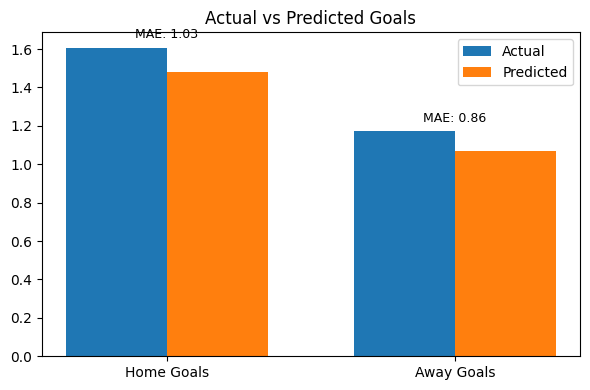

In [37]:
y_home_pred = home_goals_model.predict(X_test) #Models predicted amount of goals for each home game
y_away_pred = away_goals_model.predict(X_test) #Models predicted amount of goals for each away game

y_home_goals_acc = test_set['home_score'] #Actual score for each home game
y_away_goals_acc = test_set['away_score'] #Actual score for each away game

#Find the MAE
home_mae = abs((y_home_goals_acc - y_home_pred)).mean()
away_mae = abs((y_away_goals_acc - y_away_pred)).mean()

#Plot it
categories = ['Home Goals', 'Away Goals']
actual_means = [y_home_goals_acc.mean(), y_away_goals_acc.mean()]
pred_means   = [y_home_pred.mean(),   y_away_pred.mean()]
maes         = [home_mae, away_mae]

x = np.arange(2)
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, actual_means, width, label='Actual')
bars2 = ax.bar(x + width/2, pred_means,   width, label='Predicted')

for i, mae in enumerate(maes):
    ax.text(i, max(actual_means[i], pred_means[i]) + 0.05, 
            f'MAE: {mae:.2f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title('Actual vs Predicted Goals')
ax.legend()
plt.tight_layout()
plt.show()


Accuracy: 60.26%
Confusion Matrix Array:
 [[372   0 190]
 [161   0 272]
 [119   0 753]]


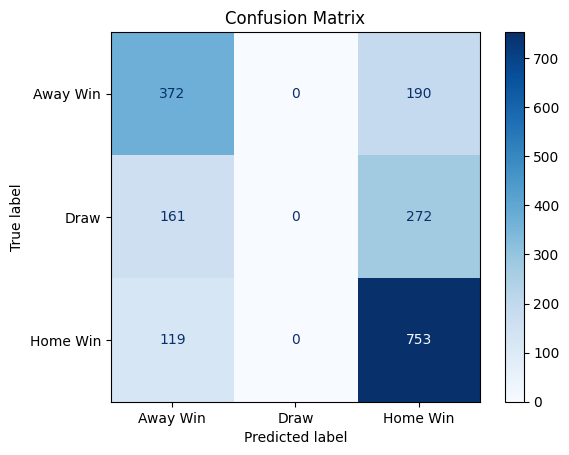

In [38]:
#Figuring out the predicted outcome
outcomes = [predict_game(h,a) for (h,a) in zip(y_home_pred, y_away_pred)]
test_set = test_set.reset_index(drop=True)
#Figuring out the predicted outcome
outcomes = [predict_game(h,a) for (h,a) in zip(y_home_pred, y_away_pred)]

X_test['p_home'] = [o[0] for o in outcomes]
X_test['p_draw'] = [o[1] for o in outcomes]
X_test['p_away'] = [o[2] for o in outcomes]

X_test['predicted'] = X_test[['p_home','p_draw','p_away']].idxmax(axis=1).str.replace('p_', '')

#Figuring out the actual outcome
X_test = X_test.reset_index(drop=True)
X_test['actual'] = test_set['target'].reset_index(drop=True)
#Figuring out accuracy
accuracy = (X_test['actual'] == X_test['predicted']).sum()
print(f"Accuracy: {(accuracy/len(X_test))*100:.2f}%")

classes = ['Away Win', 'Draw', 'Home Win']

y_true = X_test['actual']
y_pred = X_test['predicted']

#Generate the 3x3 confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix Array:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
joblib.dump(home_goals_model, 'home_goals_model.joblib')
joblib.dump(away_goals_model, 'away_goals_model.joblib')
joblib.dump(X_train.columns.tolist(), "model_features.joblib")